# Quasi-Monte Carlo Methods: Sobol Sequences & Latin Hypercube Sampling

This notebook explores **Quasi-Monte Carlo (QMC)** methods, which use deterministic low-discrepancy sequences instead of pseudo-random numbers to achieve faster convergence in numerical integration and simulation.

We cover:
1. **Latin Hypercube Sampling (LHS)** — stratified sampling in each dimension
2. **Sobol sequences** — low-discrepancy sequences with excellent space-filling properties
3. **Convergence comparison** — empirical verification of $O(N^{-1})$ vs $O(N^{-1/2})$

Monte Carlo error decays as $O(N^{-1/2})$, while QMC methods can achieve near $O(N^{-1})$ in moderate dimensions.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Try to import scipy's QMC module for Sobol sequences
try:
    from scipy.stats import qmc
    HAS_SCIPY_QMC = True
except ImportError:
    HAS_SCIPY_QMC = False
    print("Note: scipy not available. Using Halton sequences as a fallback for QMC demos.")


## 1. Standard Monte Carlo vs Quasi-Monte Carlo

**Standard MC** uses pseudo-random points. In 2D, these exhibit **clustering** and **gaps**.

**QMC** uses deterministic sequences designed to minimize **discrepancy** — a measure of how uniformly the points fill space.

The **Koksma-Hlawka inequality** bounds integration error:
$$\left| \int_{[0,1]^d} f(x) dx - \frac{1}{N}\sum_{i=1}^N f(x_i) \right| \leq V(f) \cdot D_N^*$$

where $V(f)$ is the variation of $f$ and $D_N^*$ is the star discrepancy. For QMC, $D_N^* = O((\log N)^d / N)$, yielding effective convergence near $O(N^{-1})$ for moderate dimensions.


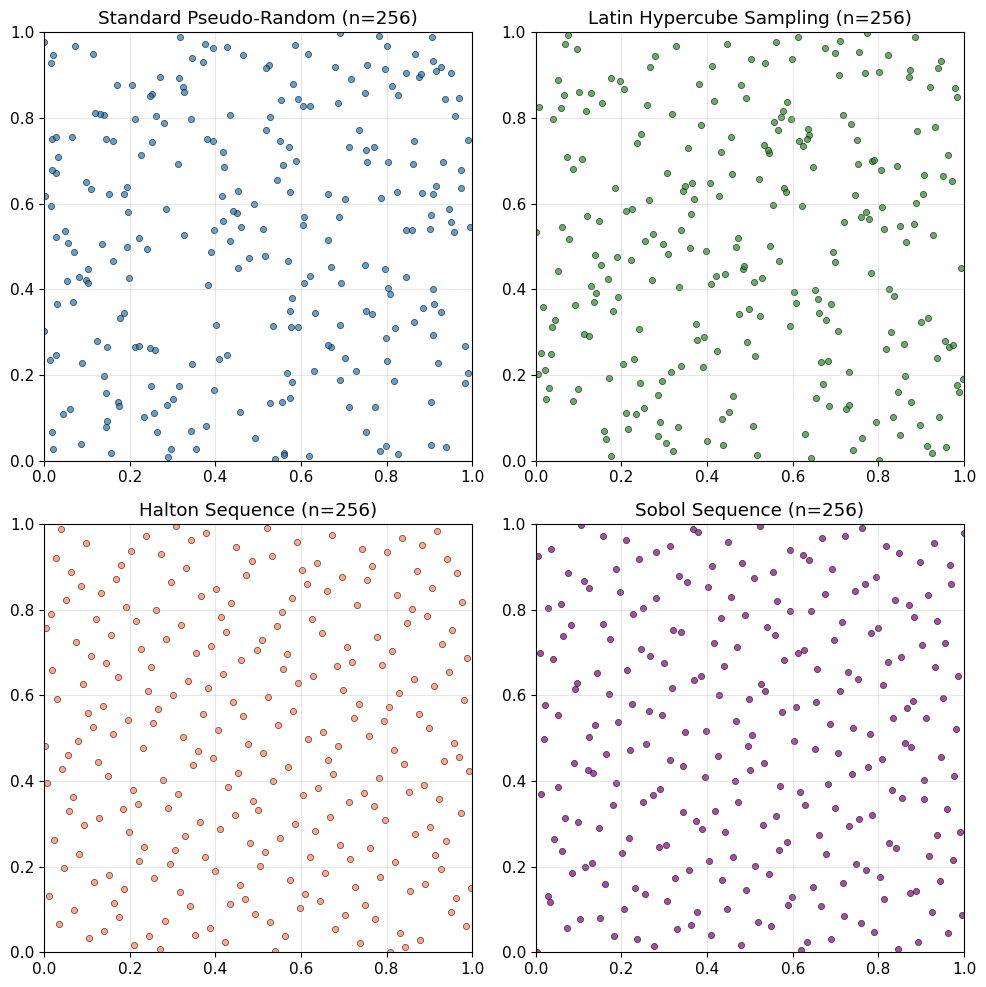

In [10]:
n = 256

# Standard pseudo-random
np.random.seed(1)
rand_2d = np.random.rand(n, 2)

# Latin Hypercube Sampling
def lhs_sample(n, d):
    result = np.zeros((n, d))
    for i in range(d):
        perm = np.random.permutation(n)
        result[:, i] = (perm + np.random.uniform(0.0, 1.0, n)) / n
    return result

lhs_2d = lhs_sample(n, 2)

# Halton sequence (pure numpy fallback)
def halton_sequence(n, d):
    bases = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29][:d]
    result = np.zeros((n, d))
    for dim in range(d):
        base = bases[dim]
        seq = np.zeros(n)
        for i in range(n):
            f = 1.0
            r = 0.0
            idx = i + 1
            while idx > 0:
                f = f / base
                r = r + f * (idx % base)
                idx = idx // base
            seq[i] = r
        result[:, dim] = seq
    return result

halton_2d = halton_sequence(n, 2)

# Sobol via scipy if available
if HAS_SCIPY_QMC:
    sampler = qmc.Sobol(d=2, scramble=True)
    sobol_2d = sampler.random(n)
else:
    sobol_2d = halton_2d.copy()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].scatter(rand_2d[:, 0], rand_2d[:, 1], s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0, 0].set_title('Standard Pseudo-Random (n={})'.format(n))
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(lhs_2d[:, 0], lhs_2d[:, 1], s=20, alpha=0.7, color='forestgreen', edgecolors='black', linewidth=0.5)
axes[0, 1].set_title('Latin Hypercube Sampling (n={})'.format(n))
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_aspect('equal')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(halton_2d[:, 0], halton_2d[:, 1], s=20, alpha=0.7, color='coral', edgecolors='black', linewidth=0.5)
axes[1, 0].set_title('Halton Sequence (n={})'.format(n))
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, alpha=0.3)

title_sobol = 'Sobol Sequence (n={})'.format(n) if HAS_SCIPY_QMC else 'Halton Fallback (n={})'.format(n)
axes[1, 1].scatter(sobol_2d[:, 0], sobol_2d[:, 1], s=20, alpha=0.7, color='purple', edgecolors='black', linewidth=0.5)
axes[1, 1].set_title(title_sobol)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_aspect('equal')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Latin Hypercube Sampling (LHS)

LHS is a stratified sampling technique that ensures exactly one sample lies in each equi-probabilistic interval of every dimension.

**Algorithm:**
1. Divide each dimension into $N$ equal strata: $[0, 1/N), [1/N, 2/N), \dots$
2. Randomly permute the stratum indices for each dimension independently.
3. Place one point uniformly within its assigned stratum.

**Properties:**
- Marginal distributions are perfectly uniform.
- No guarantee of good space-filling in the joint distribution (unless optimized).
- Variance for additive functions: $\text{Var}_{\text{LHS}} \approx \text{Var}_{\text{MC}} / N$.

We visualize the 1D projections to show the perfect stratification.


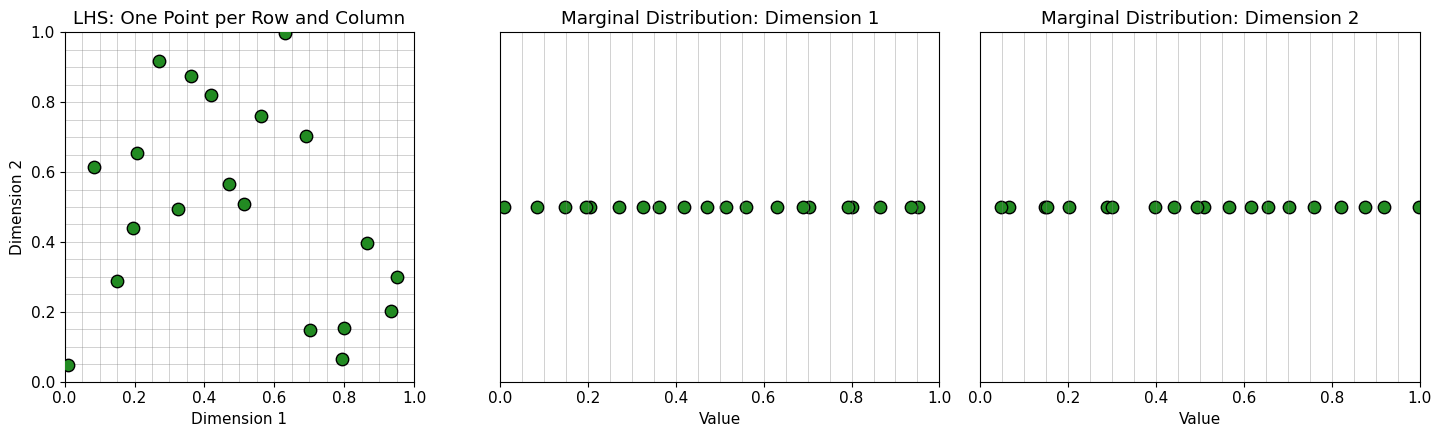

Sample mean variance comparison (Uniform[0,1], n=100)
Standard MC:  9.037204e-04
LHS:          8.061292e-08
Ratio:        11210.61x


In [11]:
n_lhs = 20
lhs_points = lhs_sample(n_lhs, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 2D scatter with grid
axes[0].scatter(lhs_points[:, 0], lhs_points[:, 1], s=80, color='forestgreen', edgecolors='black', zorder=5)
for i in range(n_lhs + 1):
    axes[0].axhline(i / n_lhs, color='gray', lw=0.5, alpha=0.5)
    axes[0].axvline(i / n_lhs, color='gray', lw=0.5, alpha=0.5)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')
axes[0].set_title('LHS: One Point per Row and Column')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(False)

# 1D projection X
axes[1].scatter(lhs_points[:, 0], np.zeros(n_lhs) + 0.5, s=80, color='forestgreen', edgecolors='black')
for i in range(n_lhs + 1):
    axes[1].axvline(i / n_lhs, color='gray', lw=0.5, alpha=0.5)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Marginal Distribution: Dimension 1')
axes[1].set_xlabel('Value')
axes[1].set_yticks([])
axes[1].grid(False)

# 1D projection Y
axes[2].scatter(lhs_points[:, 1], np.zeros(n_lhs) + 0.5, s=80, color='forestgreen', edgecolors='black')
for i in range(n_lhs + 1):
    axes[2].axvline(i / n_lhs, color='gray', lw=0.5, alpha=0.5)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].set_title('Marginal Distribution: Dimension 2')
axes[2].set_xlabel('Value')
axes[2].set_yticks([])
axes[2].grid(False)

plt.tight_layout()
plt.show()

# Compare variance of sample mean for uniform[0,1]
n_test = 100
n_runs = 1000
means_mc = [np.mean(np.random.rand(n_test)) for _ in range(n_runs)]
means_lhs = [np.mean(lhs_sample(n_test, 1)) for _ in range(n_runs)]

print("Sample mean variance comparison (Uniform[0,1], n={})".format(n_test))
print("Standard MC:  {:.6e}".format(np.var(means_mc, ddof=1)))
print("LHS:          {:.6e}".format(np.var(means_lhs, ddof=1)))
print("Ratio:        {:.2f}x".format(np.var(means_mc, ddof=1) / np.var(means_lhs, ddof=1)))


## 3. Sobol Sequences

Sobol sequences are a family of digital $(t, m, s)$-nets in base 2. They achieve exceptionally low discrepancy by ensuring that every dyadic box of a certain size contains the correct number of points.

**Key properties:**
- Base 2 arithmetic allows fast bitwise generation via Gray codes.
- **Property A**: Each dyadic interval of volume $1/2N$ contains exactly one point.
- Scrambling (e.g., Owen scrambling) improves performance for integrands with high effective dimension.

**Scrambling** randomizes the sequence while preserving the low-discrepancy structure, allowing for error estimation via replication.

> If `scipy` is unavailable, the code falls back to **Halton sequences**, which are also low-discrepancy but use different prime bases per dimension.


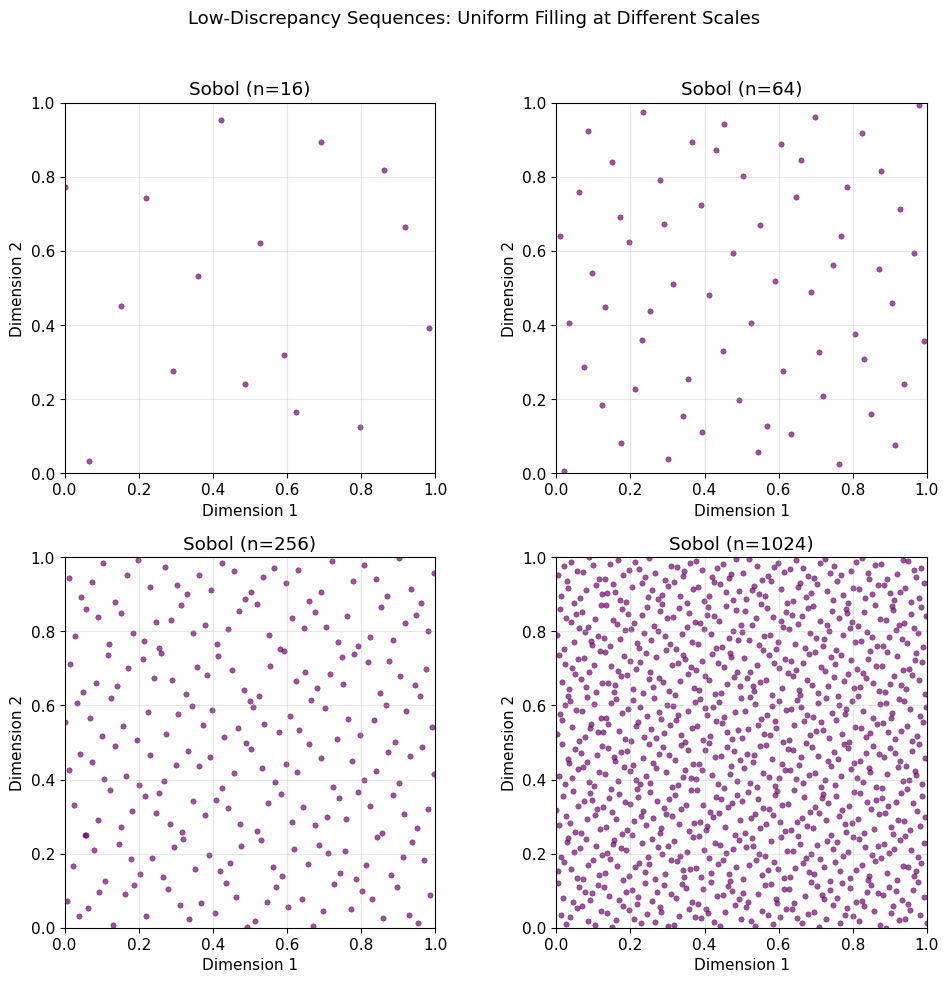

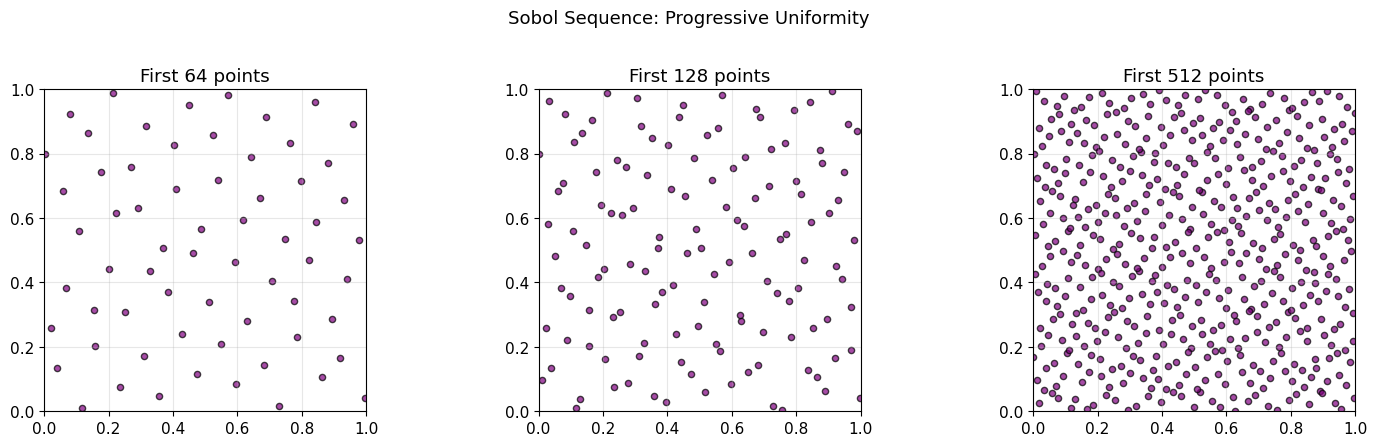

In [12]:
# Demonstrate Sobol/Halton properties with increasing N
Ns = [16, 64, 256, 1024]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for idx, n in enumerate(Ns):
    ax = axes[idx // 2, idx % 2]
    
    if HAS_SCIPY_QMC:
        sampler = qmc.Sobol(d=2, scramble=True)
        pts = sampler.random(n)
        title = 'Sobol (n={})'.format(n)
    else:
        pts = halton_sequence(n, 2)
        title = 'Halton (n={})'.format(n)
    
    ax.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.7, color='purple', edgecolors='black', linewidth=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Low-Discrepancy Sequences: Uniform Filling at Different Scales', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Show successive points fill space incrementally
if HAS_SCIPY_QMC:
    sampler = qmc.Sobol(d=2, scramble=True)
    full_pts = sampler.random(512)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, n_sub in zip(axes, [64, 128, 512]):
        ax.scatter(full_pts[:n_sub, 0], full_pts[:n_sub, 1], s=20, alpha=0.7, color='purple', edgecolors='black')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.set_title('First {} points'.format(n_sub))
        ax.grid(True, alpha=0.3)
    plt.suptitle('Sobol Sequence: Progressive Uniformity', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## 4. Convergence Analysis: MC vs LHS vs QMC

We estimate the integral:
$$I = \int_{[0,1]^2} e^{x+y} \, dx \, dy = (e - 1)^2 \approx 2.9525$$

For each method, we compute the absolute error as a function of $N$ and verify:
- **Standard MC**: error $\sim O(N^{-1/2})$
- **LHS**: error $\sim O(N^{-1/2})$ but with smaller constant (often 5-10x variance reduction)
- **QMC (Sobol/Halton)**: error $\sim O(N^{-1})$ (up to log factors)

Because QMC is deterministic, we use **randomized QMC** (scrambled Sobol or random-start Halton) to enable replication and error estimation.


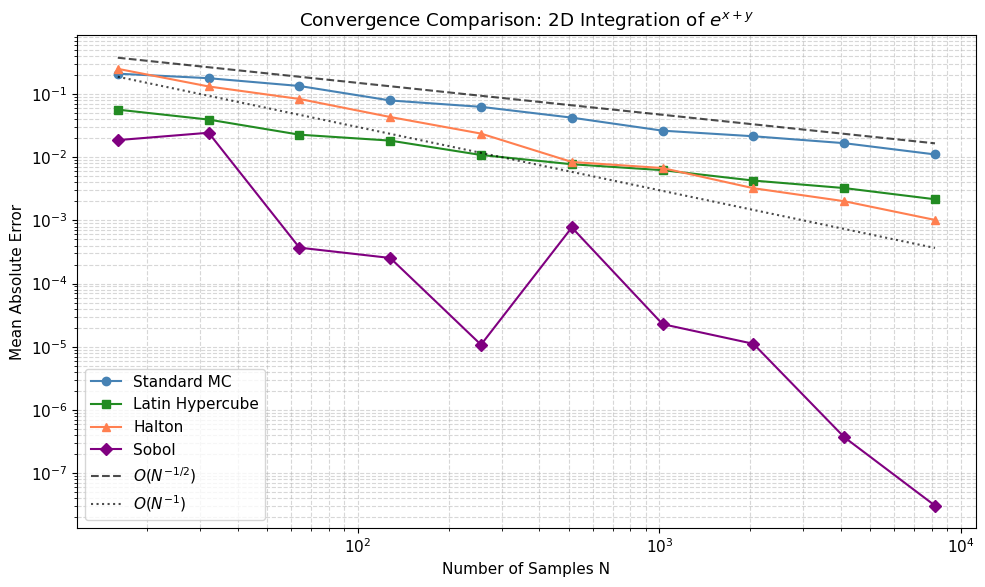

Observed convergence rates (log-log slope):
Standard MC:   -0.411
LHS:           -0.498
Halton:        -0.886
Sobol:         -3.353


In [13]:
true_val_2d = (np.exp(1.0) - 1.0)**2
f_int = lambda x, y: np.exp(x + y)

def mc_integrate_2d(n):
    x = np.random.rand(n)
    y = np.random.rand(n)
    return np.mean(f_int(x, y))

def lhs_integrate_2d(n):
    pts = lhs_sample(n, 2)
    return np.mean(f_int(pts[:, 0], pts[:, 1]))

def halton_integrate_2d(n):
    pts = halton_sequence(n, 2)
    return np.mean(f_int(pts[:, 0], pts[:, 1]))

def sobol_integrate_2d(n):
    if HAS_SCIPY_QMC:
        sampler = qmc.Sobol(d=2, scramble=True)
        pts = sampler.random(n)
    else:
        pts = halton_sequence(n, 2)
    return np.mean(f_int(pts[:, 0], pts[:, 1]))

N_vals = np.array([16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192])

# For MC and LHS, average over multiple runs to get stable error estimates
n_runs = 100
errors_mc = []
errors_lhs = []
errors_halton = []
errors_sobol = []

for N in N_vals:
    errs_mc = [abs(mc_integrate_2d(N) - true_val_2d) for _ in range(n_runs)]
    errs_lhs = [abs(lhs_integrate_2d(N) - true_val_2d) for _ in range(n_runs)]
    errors_mc.append(np.mean(errs_mc))
    errors_lhs.append(np.mean(errs_lhs))
    # QMC is deterministic (or single randomized draw)
    errors_halton.append(abs(halton_integrate_2d(N) - true_val_2d))
    errors_sobol.append(abs(sobol_integrate_2d(N) - true_val_2d))

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(N_vals, errors_mc, 'o-', label='Standard MC', color='steelblue')
ax.loglog(N_vals, errors_lhs, 's-', label='Latin Hypercube', color='forestgreen')
ax.loglog(N_vals, errors_halton, '^-', label='Halton', color='coral')
sobol_label = 'Sobol' if HAS_SCIPY_QMC else 'Sobol (Halton fallback)'
ax.loglog(N_vals, errors_sobol, 'D-', label=sobol_label, color='purple')

# Reference slopes
ax.loglog(N_vals, 1.5 / np.sqrt(N_vals), 'k--', alpha=0.7, label=r'$O(N^{-1/2})$')
ax.loglog(N_vals, 3.0 / N_vals, 'k:', alpha=0.7, label=r'$O(N^{-1})$')

ax.set_xlabel('Number of Samples N')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Convergence Comparison: 2D Integration of $e^{x+y}$')
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print observed convergence rates (log-log slope for last few points)
def log_slope(N, err):
    return np.polyfit(np.log(N).astype(float), np.log(err), 1)[0]

print("Observed convergence rates (log-log slope):")
print("Standard MC:   {:.3f}".format(log_slope(N_vals[-4:], errors_mc[-4:])))
print("LHS:           {:.3f}".format(log_slope(N_vals[-4:], errors_lhs[-4:])))
print("Halton:        {:.3f}".format(log_slope(N_vals[-4:], errors_halton[-4:])))
print("Sobol:         {:.3f}".format(log_slope(N_vals[-4:], errors_sobol[-4:])))


## 5. Higher-Dimensional Integration

A key advantage of QMC is that the convergence rate does not degrade exponentially with dimension (unlike tensor-product quadrature). However, the hidden constant $(\log N)^d$ grows with dimension $d$.

We test in $d=5$ dimensions:
$$I = \int_{[0,1]^5} \exp\left(-\sum_{i=1}^5 x_i\right) dx = (1 - e^{-1})^5$$

Note that Sobol sequences can struggle in very high dimensions unless the effective dimension is low (e.g., via dimension-adaptive methods or Brownian bridge constructions for path-dependent options).


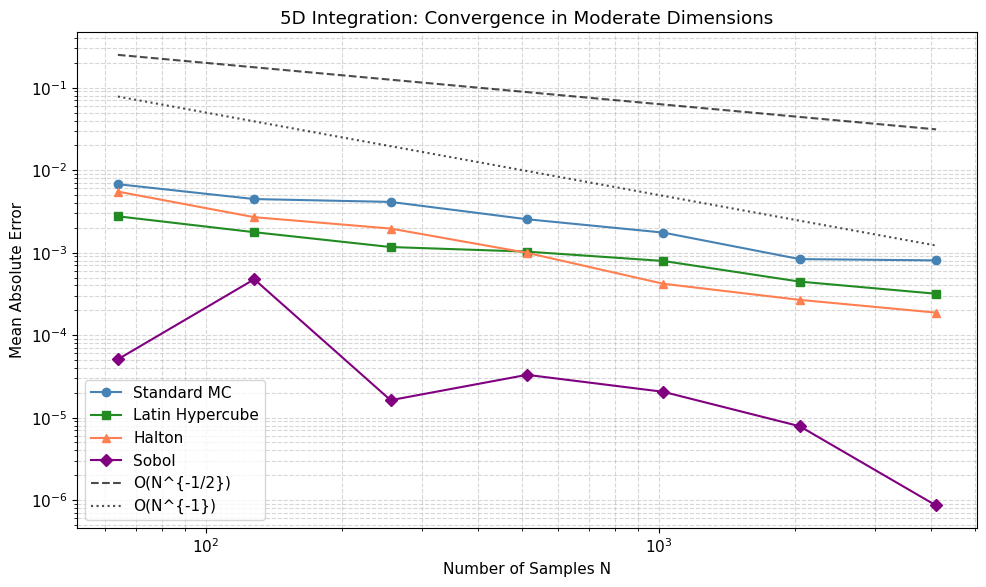

5D True value: 0.100925
Final errors at N=4096:
  MC:    8.062145e-04
  LHS:   3.176387e-04
  Halton:1.875193e-04
  Sobol: 8.613924e-07


In [15]:
d = 5
true_val_5d = (1.0 - np.exp(-1.0))**d
f_5d = lambda pts: np.exp(-np.sum(pts, axis=1))

def mc_5d(n):
    pts = np.random.rand(n, d)
    return np.mean(f_5d(pts))

def lhs_5d(n):
    pts = lhs_sample(n, d)
    return np.mean(f_5d(pts))

def halton_5d(n):
    pts = halton_sequence(n, d)
    return np.mean(f_5d(pts))

def sobol_5d(n):
    if HAS_SCIPY_QMC:
        # Sobol balance properties require N = 2^m; use random_base2 to avoid warnings
        m = int(np.log2(n))
        sampler = qmc.Sobol(d=d, scramble=True)
        pts = sampler.random_base2(m)
        return np.mean(f_5d(pts))
    else:
        pts = halton_sequence(n, d)
        return np.mean(f_5d(pts))

# Use powers of 2 so QMC sequences maintain their balance properties
N_vals_5d = np.array([64, 128, 256, 512, 1024, 2048, 4096])
n_runs_5d = 50

errors_mc_5d = []
errors_lhs_5d = []
errors_halton_5d = []
errors_sobol_5d = []

for N in N_vals_5d:
    errs_mc = [abs(mc_5d(N) - true_val_5d) for _ in range(n_runs_5d)]
    errs_lhs = [abs(lhs_5d(N) - true_val_5d) for _ in range(n_runs_5d)]
    errors_mc_5d.append(np.mean(errs_mc))
    errors_lhs_5d.append(np.mean(errs_lhs))
    errors_halton_5d.append(abs(halton_5d(N) - true_val_5d))
    errors_sobol_5d.append(abs(sobol_5d(N) - true_val_5d))

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(N_vals_5d, errors_mc_5d, 'o-', label='Standard MC', color='steelblue')
ax.loglog(N_vals_5d, errors_lhs_5d, 's-', label='Latin Hypercube', color='forestgreen')
ax.loglog(N_vals_5d, errors_halton_5d, '^-', label='Halton', color='coral')
sobol_label_5d = 'Sobol' if HAS_SCIPY_QMC else 'Sobol (Halton fallback)'
ax.loglog(N_vals_5d, errors_sobol_5d, 'D-', label=sobol_label_5d, color='purple')
ax.loglog(N_vals_5d, 2.0 / np.sqrt(N_vals_5d), 'k--', alpha=0.7, label='O(N^{-1/2})')
ax.loglog(N_vals_5d, 5.0 / N_vals_5d, 'k:', alpha=0.7, label='O(N^{-1})')

ax.set_xlabel('Number of Samples N')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('5D Integration: Convergence in Moderate Dimensions')
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("5D True value: {:.6f}".format(true_val_5d))
print("Final errors at N={}:".format(N_vals_5d[-1]))
print("  MC:    {:.6e}".format(errors_mc_5d[-1]))
print("  LHS:   {:.6e}".format(errors_lhs_5d[-1]))
print("  Halton:{:.6e}".format(errors_halton_5d[-1]))
print("  Sobol: {:.6e}".format(errors_sobol_5d[-1]))


## 6. Summary and Practical Recommendations

| Method | Convergence | Best For | Limitations |
|--------|-------------|----------|-------------|
| **Standard MC** | $O(N^{-1/2})$ | General purpose, easy error estimation | Slow, clustering artifacts |
| **LHS** | $O(N^{-1/2})$ with small constant | Moderate dimensions, black-box simulators | No joint space-filling guarantee |
| **Halton** | $\approx O(N^{-1})$ | Low dimensions ($d \leq 10$) | Correlation in high dimensions |
| **Sobol** | $\approx O(N^{-1})$ | Finance, moderate dimensions ($d \leq 50$) | Requires careful initialization |

### Practical Tips
1. **Always scramble** Sobol/Halton sequences when replication is needed for confidence intervals.
2. **Effective dimension** matters more than nominal dimension. Use dimension-adaptive strategies or Brownian bridge constructions for path-dependent options.
3. **Combine with antithetic variates** or control variates for further gains.
4. For $d > 50$, consider **lattice rules** or **sparse grids** instead of standard Sobol.
5. 